# **Data Collection**

## Objectives

* Download data from Kaggle.com and perform an initial EDA.

## Inputs

* unclean_smartwatch_health_data.csv

## Outputs

* ydata-profiling EDA

## Additional Comments

* In case you have any additional comments that don't fit in the previous bullets, please state them here. 

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project'

Setup needed variables

In [4]:
InputFolder = "inputs/"
OutputFolder = "outputs/"
UntouchedData = InputFolder + "smartwatch_health_data_untouched/"
CleanedData = InputFolder + "cleaned_data/"

In [5]:
version = "v1"

OutputFolder = f"outputs/{version}/cluster_task/"
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

## Step 1: Load Data

Load data and drop User ID

In [6]:
import pandas as pd

df = pd.read_csv(UntouchedData + "unclean_smartwatch_health_data.csv").drop("User ID", axis=1)
df.head()

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


## Step 2: Data Cleaning

Declare custom transformers

In [7]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Replace 'Very High' with 10 in 'Stress Level' and convert columns to numeric
class DataTypeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Replace 'Very High' with 10 in 'Stress Level'
        X['Stress Level'] = X['Stress Level'].replace('Very High', 10)

        # Convert columns to numeric, handling non-numeric values
        X['Sleep Duration (hours)'] = pd.to_numeric(X['Sleep Duration (hours)'], errors='coerce')
        X['Stress Level'] = pd.to_numeric(X['Stress Level'], errors='coerce')

        return X


# Impute missing values (not for Activity Level)
from sklearn.impute import KNNImputer

class KNNImputerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors
        self.imputer = KNNImputer(n_neighbors=self.n_neighbors)

    def fit(self, X, y=None):
        # Identify numerical columns
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.imputer.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        # Impute numerical columns
        X[self.num_cols] = self.imputer.transform(X[self.num_cols])
        return X


# Handle Outliers
from feature_engine.outliers import Winsorizer

class WinsorizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.winsorizers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Winsorizers for each variable
        self.winsorizers['Sleep Duration (hours)'] = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.winsorizers['Heart Rate (BPM)'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.winsorizers['Blood Oxygen Level (%)'] = Winsorizer(
            capping_method='iqr', tail='left', fold=1.5, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.winsorizers['Step Count'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Winsorizers
        for winsorizer in self.winsorizers.values():
            X = winsorizer.transform(X)
        return X


class FloatToInt(BaseEstimator, TransformerMixin):
    def __init__(self, columns=['Stress Level']):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert specified columns to integer
        for col in self.columns:
            X[col] = X[col].astype(int)
        return X

# Predict missing values in 'Activity Level'
from sklearn.ensemble import RandomForestClassifier

class CategoricalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_column='Activity Level', random_state=42):
        self.target_column = target_column
        self.random_state = random_state
        self.classifier = RandomForestClassifier(random_state=self.random_state)
        self.original_categories = None

    def fit(self, X, y=None):
        X = X.copy()
        # Save original categories
        X[self.target_column] = X[self.target_column].astype('category')
        self.original_categories = X[self.target_column].cat.categories

        # Encode target column
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Split data
        self.train_data = X.dropna(subset=[self.target_column])
        self.test_data = X[X[self.target_column].isna()]

        # Features and target
        self.X_train = self.train_data.drop(columns=[self.target_column])
        self.y_train = self.train_data[self.target_column].astype(int)

        # Fit classifier
        self.classifier.fit(self.X_train, self.y_train)
        return self

    def transform(self, X):
        X = X.copy()
        # Encode target column
        X[self.target_column] = X[self.target_column].astype('category')
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Identify missing values
        missing_mask = X[self.target_column].isna()
        if missing_mask.any():
            X_missing = X[missing_mask]
            X_missing_features = X_missing.drop(columns=[self.target_column])
            # Predict missing values
            X.loc[missing_mask, self.target_column] = self.classifier.predict(X_missing_features)

        # Convert to int and decode categories
        X[self.target_column] = X[self.target_column].astype(int)
        X[self.target_column] = pd.Categorical.from_codes(
            X[self.target_column], categories=self.original_categories
        )
        return X


# Correct mis-spelled values in Activity Level
class CategoryCorrector(BaseEstimator, TransformerMixin):
    def __init__(self, column='Activity Level'):
        self.column = column
        self.class_mapping = {
            'Seddentary': 'Sedentary',
            'Highly_Active': 'Highly Active',
            'Actve': 'Active'
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = X[self.column].replace(self.class_mapping)
        return X


# Smooth data using K-Nearest Neighbors
from sklearn.neighbors import NearestNeighbors

class DataSmoother(BaseEstimator, TransformerMixin):
    def __init__(self, k=3):
        self.k = k
        self.nn = NearestNeighbors(n_neighbors=self.k)

    def fit(self, X, y=None):
        X = X.copy()
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.nn.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        distances, indices = self.nn.kneighbors(X[self.num_cols])

        # Smooth numerical columns
        for i, col in enumerate(self.num_cols):
            X[col] = [np.mean(X.iloc[indices[row_idx]][col]) for row_idx in range(len(X))]
        return X


# Trim outliers again after smoothing
from feature_engine.outliers import OutlierTrimmer

class OutlierTrimmerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.trimmers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Outlier Trimmers for each variable
        self.trimmers['Heart Rate (BPM)'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.trimmers['Blood Oxygen Level (%)'] = OutlierTrimmer(
            capping_method='quantiles', tail='left', fold=0.05, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.trimmers['Sleep Duration (hours)'] = OutlierTrimmer(
            capping_method='quantiles', tail='both', fold=0.05, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.trimmers['Step Count'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Outlier Trimmers sequentially
        for trimmer in self.trimmers.values():
            X = trimmer.transform(X)
        return X

# This is important else even the categoric column will be minmax scaled resulting in much different components when evaluated with a PCA
from sklearn.preprocessing import MinMaxScaler , StandardScaler , RobustScaler
class DataFrameScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_columns=None):
        self.exclude_columns = exclude_columns
        self.scaler = RobustScaler()
    
    def fit(self, X, y=None):
        X_to_scale = X.drop(columns=self.exclude_columns)
        self.scaler.fit(X_to_scale)
        return self
    
    def transform(self, X):
        X_to_scale = X.drop(columns=self.exclude_columns)
        X_excluded = X[self.exclude_columns]
        X_scaled = pd.DataFrame(self.scaler.transform(X_to_scale), columns=X_to_scale.columns)
        X_final = pd.concat([X_scaled, X_excluded.reset_index(drop=True)], axis=1)
        return X_final

## Step 2: Feature Engineering

We researched for the optimal values for n_components and n_clusters in the engineering notebook. I will be using the smoothed dataset for this modelling. From viewing plots, I have learned the smoothed set doesnt need a numerical transformation, as it doesnt have a positive effect.

In [8]:
from sklearn.pipeline import Pipeline
# encoding
from feature_engine.encoding import OrdinalEncoder, OneHotEncoder
# pca
from sklearn.decomposition import PCA
# kmeans
from sklearn.cluster import KMeans
# scale
from sklearn.preprocessing import StandardScaler
# column transformer
from sklearn.compose import ColumnTransformer

def CleanEnginPipeline():
    cleaning_engineering_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        # I have chosen OrdinalEncoder as our categorical variables have an ordinal relationship
        ('minmax', DataFrameScaler(exclude_columns=["Activity Level", "Stress Level"])),
        ('float_to_int', FloatToInt()),
    ])
    return cleaning_engineering_pipeline

Use this cleaned version variable later

In [9]:
df_cleaned = CleanEnginPipeline().fit_transform(df)
df_cleaned = pd.DataFrame(df_cleaned, columns=df.columns)
df_cleaned.head()

/tmp/ipykernel_75201/3730909374.py:159: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[self.column] = X[self.column].replace(self.class_mapping)


,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,-0.705278,-0.146973,0.097743,0.307473,0,3
1,-0.257220,0.127086,-0.579059,-0.647565,0,6
2,-1.688744,0.065933,1.292815,0.683501,1,2
3,-0.984975,-0.041568,1.562748,-0.624565,0,4
4,0.519655,-0.687826,0.779591,1.215051,0,8


In [10]:
def FullPipeline():
    cleaning_engineering_pipeline = CleanEnginPipeline()
    clustering_pipeline = Pipeline([
        ('cleaning_engineering_pipeline', cleaning_engineering_pipeline),
        ('pca', PCA(n_components=3, random_state=42)),
        ('model', KMeans(n_clusters=6, random_state=42))
    ])
    return clustering_pipeline

Lets double check the components to make sure the custom transformers are doing what they are supposed to. And check the elbow and silhouette plots again, to make sure they are similar to the plot tests done in the engineering notebook.

In [11]:
full_pipeline = FullPipeline()
pipeline_pca = Pipeline(full_pipeline.steps[:-2])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape,'\n', type(df_pca))

/tmp/ipykernel_75201/3730909374.py:159: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[self.column] = X[self.column].replace(self.class_mapping)


(7800, 6) 
 <class 'pandas.core.frame.DataFrame'>


When attempting this PCA without scaling, component 0 (Activity Level always takes 99% of the varience)

In [12]:
n_components = 3

pca = PCA(n_components=n_components).fit(df_pca) 
x_PCA = pca.transform(df_pca) 

ComponentsList = ["Component " + str(number) for number in range(n_components)]
dfExplVarRatio = pd.DataFrame(
    data= np.round(100 * pca.explained_variance_ratio_ ,3),
    index=ComponentsList,
    columns=['Explained Variance Ratio (%)'])

# prints how much of the dataset these components explain (naturally in this case will be 100%)
PercentageOfDataExplained = dfExplVarRatio['Explained Variance Ratio (%)'].sum()

print(f"* The {n_components} components explain {round(PercentageOfDataExplained,2)}% of the data \n")
print(dfExplVarRatio)

* The 3 components explain 79.11% of the data 

             Explained Variance Ratio (%)
Component 0                        60.469
Component 1                        10.507
Component 2                         8.138


I can explain 100% of the data with 5 components. Component 0 is the most powerfull, with a ratio of 72.094% of the data variance. Component 1 is also powerfull, but the main reason is because these values were not scaled, as they are already in a simple interger format. I would like to try just 2 componenets to see the outcome. As I feel the other components with a low varience wont split well into distinct clusters. I can reduce feature space if two componenets is overkill.

In [13]:
pipeline_cluster = FullPipeline()
df_analysis = pipeline_cluster.fit_transform(df)

print(df_analysis.shape,'\n', type(df_analysis))

/tmp/ipykernel_75201/3730909374.py:159: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[self.column] = X[self.column].replace(self.class_mapping)


(7800, 6) 
 <class 'numpy.ndarray'>


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


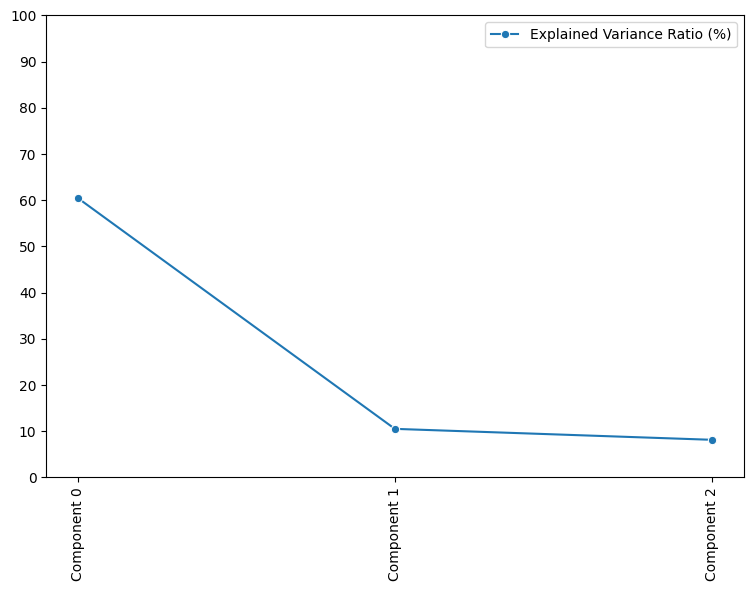

In [14]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
rcParams['font.family'] = ['DejaVu Sans']

plt.figure(figsize=(9, 6))
sns.lineplot(data=dfExplVarRatio,  marker="o")
plt.xticks(rotation=90)
plt.yticks(np.arange(0, 110, 10))
plt.savefig(OutputFolder + "ExplainedVarianceRatio.png")
plt.show()

=== Average Silhouette Score for different number of clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 1

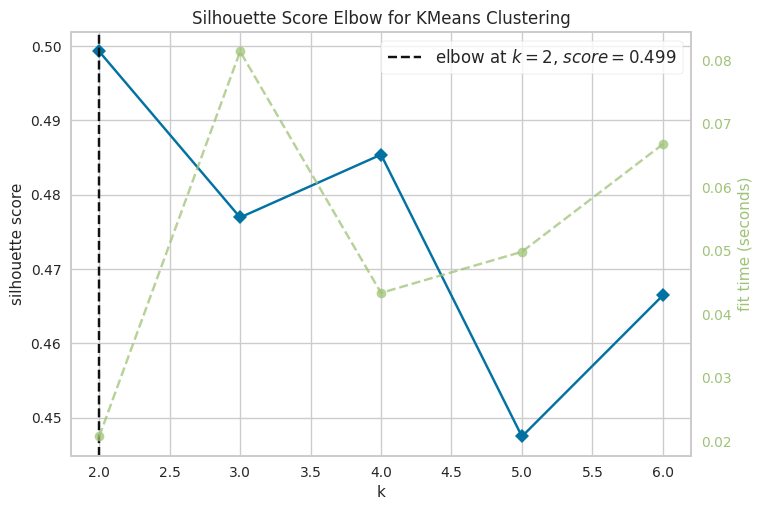



=== Silhouette plot for 2 Clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


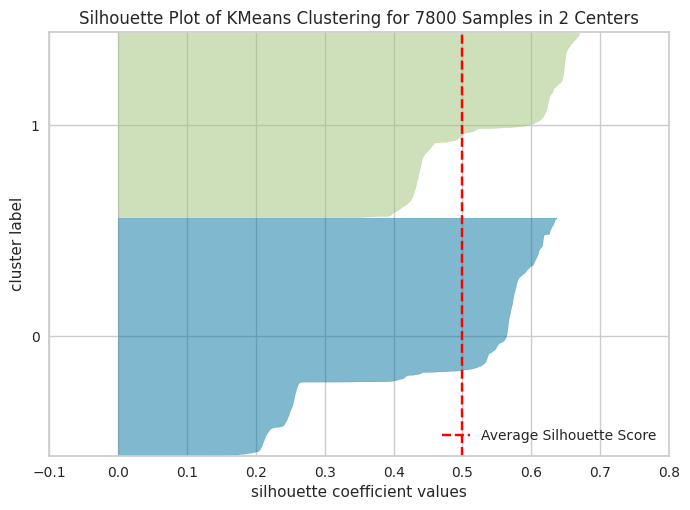



=== Silhouette plot for 3 Clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


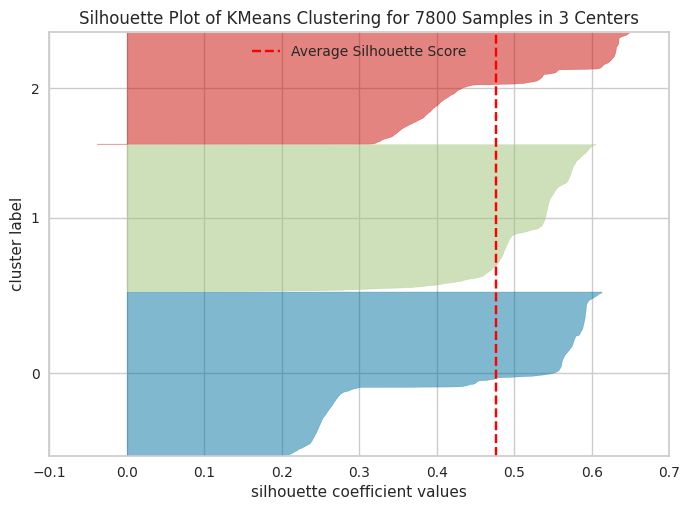



=== Silhouette plot for 4 Clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


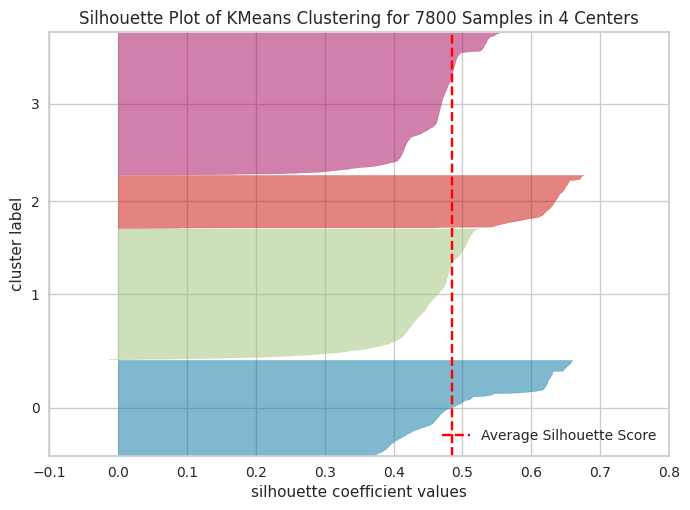



=== Silhouette plot for 5 Clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


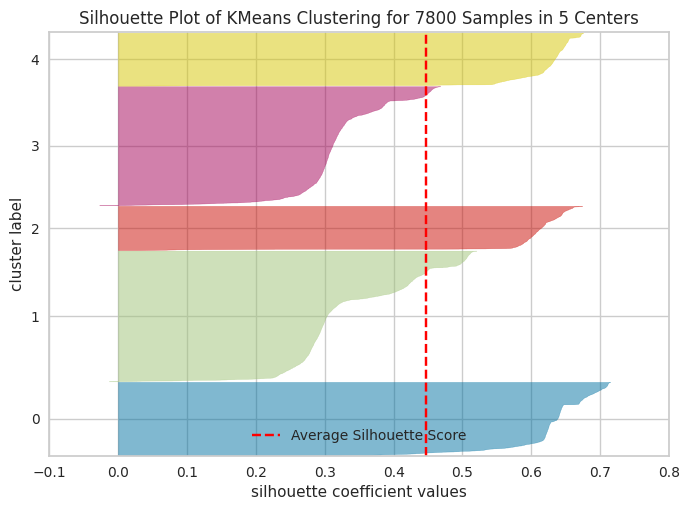



=== Silhouette plot for 6 Clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


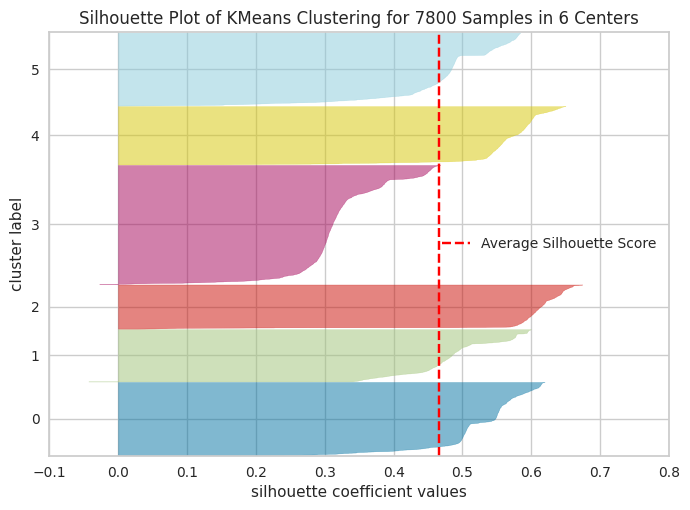



=== Silhouette plot for 7 Clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


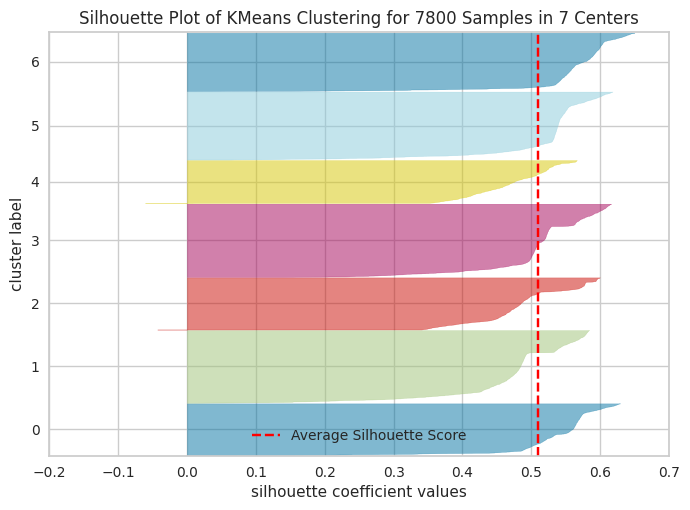



=== Silhouette plot for 8 Clusters ===


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


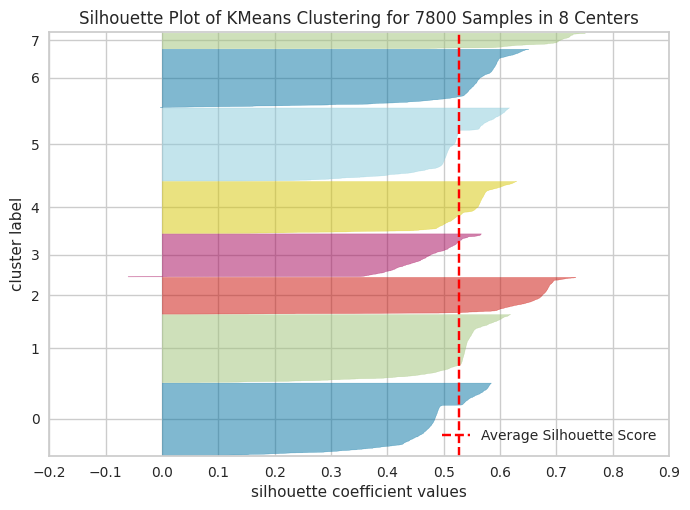

In [15]:
from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.cluster import KElbowVisualizer
from matplotlib import rcParams
rcParams['font.family'] = ['DejaVu Sans']

print("=== Average Silhouette Score for different number of clusters ===")
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,7), metric='silhouette')
visualizer.fit(df_analysis) 
visualizer.show() 
plt.savefig(os.path.join(OutputFolder, "elbow_plot.png"))
plt.close()
print("\n")

for n_clusters in np.arange(start=2,stop=9):
  
  print(f"=== Silhouette plot for {n_clusters} Clusters ===")
  visualizer = SilhouetteVisualizer(estimator = KMeans(n_clusters=n_clusters, random_state=42),
                                    colors = 'yellowbrick')
  visualizer.fit(df_analysis)
  visualizer.show()
  plt.savefig(os.path.join(OutputFolder, f"silhouette_plot_{n_clusters}_clusters.png"))
  plt.close()
  print("\n")

Looks good. The best is 3 clusters. Though i would like to try 4 first

## Train

In [16]:
pipeline_cluster = FullPipeline()
X = pipeline_cluster.fit_transform(df.copy())
X = pd.DataFrame(X)

# cluster labels
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)


/tmp/ipykernel_75201/3730909374.py:159: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[self.column] = X[self.column].replace(self.class_mapping)


(7800, 7)


/home/cistudent/.local/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,0,1,2,3,4,5,Clusters
0,0.427453,3.775991,2.941244,2.192743,5.412536,1.806536,0
1,2.920070,1.747446,0.822418,2.274007,2.612475,4.188158,2
2,1.444791,4.496252,4.055424,2.604930,6.332262,0.782798,5


* Clusters frequencies 
          proportion
Clusters            
3               0.22
1               0.21
0               0.16
2               0.16
4               0.12
5               0.12 




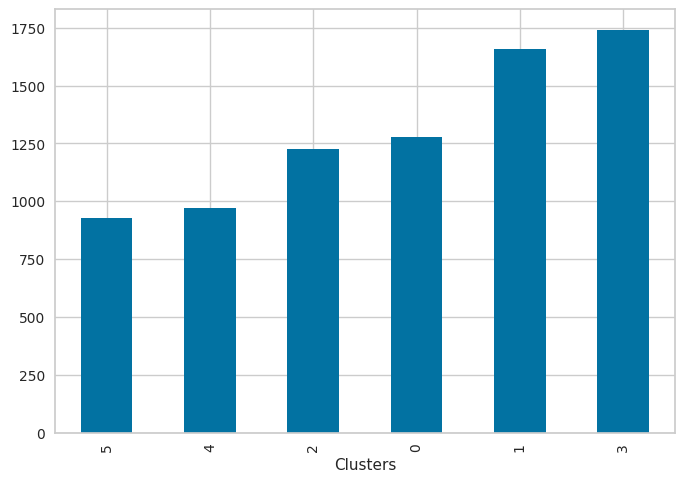

In [17]:
import matplotlib.pyplot as plt

print(f"* Clusters frequencies \n{ X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.savefig(os.path.join(OutputFolder, "cluster_frequencies.png"))
plt.show()

Great these 4 cluster profiles look good enough with respect to balance. I believe this is a alright result.

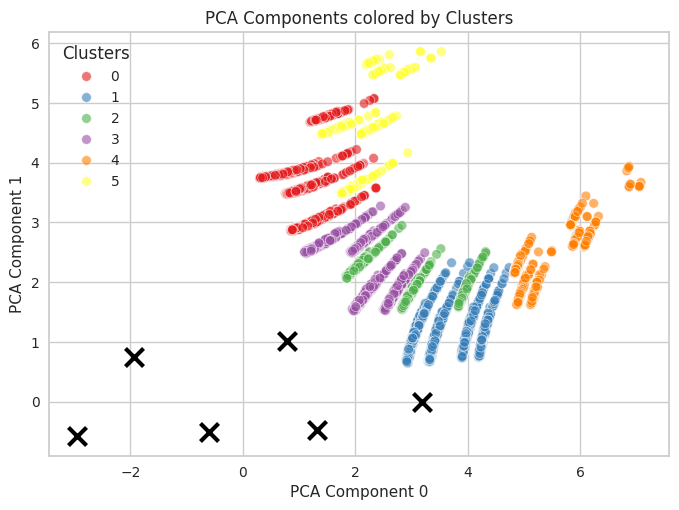

In [18]:
sns.scatterplot(x=X.columns[0], y=X.columns[1],
                hue='Clusters', palette='Set1', alpha=0.6, data=X)
plt.scatter(x=pipeline_cluster.named_steps['model'].cluster_centers_[:, 0], 
            y=pipeline_cluster.named_steps['model'].cluster_centers_[:, 1],
            marker="x", s=169, linewidths=3, color="black")
plt.xlabel("PCA Component 0")
plt.ylabel("PCA Component 1")
plt.title("PCA Components colored by Clusters")
plt.savefig(os.path.join(OutputFolder, "clustered_pca_plot.png"))
plt.show()

## Fit classifier

In [19]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(7800, 7)


,0,1,2,3,4,5,Clusters
0,0.427453,3.775991,2.941244,2.192743,5.412536,1.806536,0
1,2.920070,1.747446,0.822418,2.274007,2.612475,4.188158,2
2,1.444791,4.496252,4.055424,2.604930,6.332262,0.782798,5


Save these predictions for later

In [20]:
all_cluster_predictions = X["Clusters"].values
all_cluster_predictions

array([0, 2, 5, ..., 3, 4, 1], dtype=int32)

Split the dataset but with the target variable as "Clusters"

In [21]:

from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(
                                    df_clf.drop(['Clusters'],axis=1),
                                    df_clf['Clusters'],
                                    test_size=0.2,
                                    random_state=42
                                    )

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(6240, 6) (6240,) (1560, 6) (1560,)


In [22]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier 

def PipelineClassify():
  pipeline_base = Pipeline([
      ("feat_selection", SelectFromModel(GradientBoostingClassifier(random_state=42)) ), 
      ("model",  GradientBoostingClassifier(random_state=42) ), 
  ])
  return pipeline_base

In [23]:
pipeline_clf_cluster = PipelineClassify()
pipeline_clf_cluster.fit(X_train, y_train)

Pipeline(steps=[('feat_selection',
                 SelectFromModel(estimator=GradientBoostingClassifier(random_state=42))),
                ('model', GradientBoostingClassifier(random_state=42))])

Evaluate

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1024
           1       1.00      1.00      1.00      1311
           2       1.00      1.00      1.00       962
           3       1.00      1.00      1.00      1414
           4       1.00      1.00      1.00       796
           5       1.00      1.00      1.00       733

    accuracy                           1.00      6240
   macro avg       1.00      1.00      1.00      6240
weighted avg       1.00      1.00      1.00      6240



In [25]:
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       252
           1       1.00      1.00      1.00       345
           2       1.00      1.00      1.00       266
           3       1.00      1.00      1.00       328
           4       1.00      1.00      1.00       174
           5       1.00      1.00      1.00       195

    accuracy                           1.00      1560
   macro avg       1.00      1.00      1.00      1560
weighted avg       1.00      1.00      1.00      1560



Good generalizing capability. lets now asses the most important features that define the clusters.

In [26]:
# Get feature importances from the classifier
importances = pipeline_clf_cluster.named_steps['model'].feature_importances_

# Get the indices of the most important features
indices = np.argsort(importances)[::-1]

# Get the names of the most important features
best_features = [X_train.columns[i] for i in indices]

print("Best features in order of importance:")
print(best_features)

Best features in order of importance:
[1, 3, 0, 2]


These are the best features, though we dont know its original name yet, lets find that out.

save best features for later

In [27]:
best_features_pipeline_all_variables = best_features
best_features_pipeline_all_variables

[1, 3, 0, 2]

In [28]:
def DescriptionAllClusters(df, decimal_points=3):

    DescriptionAllClusters = pd.DataFrame(
        columns=df.drop(['Clusters'], axis=1).columns)
    # iterate on each cluster , calls Clusters_IndividualDescription()
    for cluster in df.sort_values(by='Clusters')['Clusters'].unique():

        EDA_ClusterSubset = df.query(
            f"Clusters == {cluster}").drop(['Clusters'], axis=1)
        ClusterDescription = Clusters_IndividualDescription(
            EDA_ClusterSubset, cluster, decimal_points)
        DescriptionAllClusters = pd.concat(
            [ClusterDescription, DescriptionAllClusters])

    DescriptionAllClusters.set_index(['Cluster'], inplace=True)
    return DescriptionAllClusters


def Clusters_IndividualDescription(EDA_Cluster, cluster, decimal_points):

    ClustersDescription = pd.DataFrame(columns=EDA_Cluster.columns)
    # for a given cluster, iterate over all columns
    # if the variable is numerical, calculate the IQR: display as Q1 -- Q3.
    # That will show the range for the most common values for the numerical variable
    # if the variable is categorical, count the frequencies and displays the top 3 most frequent
    # That will show the most common levels for the category

    for col in EDA_Cluster.columns:

        try:  # eventually a given cluster will have only missing data for a given variable

            if EDA_Cluster[col].dtypes == 'object':

                top_frequencies = EDA_Cluster.dropna(
                    subset=[col])[[col]].value_counts(normalize=True).nlargest(n=3)
                Description = ''

                for x in range(len(top_frequencies)):
                    freq = top_frequencies.iloc[x]
                    category = top_frequencies.index[x][0]
                    CategoryPercentage = int(round(freq*100, 0))
                    statement = f"'{category}': {CategoryPercentage}% , "
                    Description = Description + statement

                ClustersDescription.at[0, col] = Description[:-2]

            elif EDA_Cluster[col].dtypes in ['float', 'int']:
                DescStats = EDA_Cluster.dropna(subset=[col])[[col]].describe()
                Q1 = round(DescStats.iloc[4, 0], decimal_points)
                Q3 = round(DescStats.iloc[6, 0], decimal_points)
                Description = f"{Q1} -- {Q3}"
                ClustersDescription.at[0, col] = Description

        except Exception as e:
            ClustersDescription.at[0, col] = 'Not available'
            print(
                f"** Error Exception: {e} - cluster {cluster}, variable {col}")

    ClustersDescription['Cluster'] = str(cluster)

    return ClustersDescription

In [29]:
import plotly.express as px


def cluster_distribution_per_variable(df, target):
    """
    The data should have 2 variables, the cluster predictions and
    the variable you want to analyze with, in this case we call "target".
    We use plotly express to create 2 plots:
    Cluster distribution across the target.
    Relative presence of the target level in each cluster.
    """
    df_bar_plot = df.groupby(['Clusters', target]).size().reset_index(name='Count')
    df_bar_plot.columns = ['Clusters', target, 'Count']
    df_bar_plot[target] = df_bar_plot[target].astype('object')

    print(f"Clusters distribution across {target} levels")
    fig = px.bar(df_bar_plot, x='Clusters', y='Count',
                 color=target, width=800, height=500)
    fig.update_layout(xaxis=dict(tickmode='array',
                      tickvals=df['Clusters'].unique()))
    fig.show(renderer='jupyterlab')

    df_relative = (df
                   .groupby(["Clusters", target])
                   .size()
                   .unstack(fill_value=0)
                   .apply(lambda x: 100 * x / x.sum(), axis=1)
                   .stack()
                   .reset_index(name='Relative Percentage (%)')
                   .sort_values(by=['Clusters', target])
                   )

    print(f"Relative Percentage (%) of {target} in each cluster")
    fig = px.line(df_relative, x='Clusters', y='Relative Percentage (%)',
                  color=target, width=800, height=500)
    fig.update_layout(xaxis=dict(tickmode='array',
                      tickvals=df['Clusters'].unique()))
    fig.update_traces(mode='markers+lines')
    fig.show(renderer='jupyterlab')

Use the custom function above to find best cluster profile by testing each orginal, just cleaned, column name to find the one that is the most inline with the clusters. It seems Activity Level is perfectley aligned with each 3 clusters, and Stress Level only slightly with 6%. Activity Level is highly influential in determining what cluster/group an individual belongs in based on the smart watch health data. 

In [30]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(items=best_features + ['Clusters'], axis=1)
df_active = df_cleaned["Activity Level"].astype('object')
df_stress = df_cleaned["Stress Level"].astype('object')
df_step = df_cleaned["Step Count"].astype('object')
df_blood = df_cleaned["Blood Oxygen Level (%)"].astype('object')
df_heart = df_cleaned["Heart Rate (BPM)"].astype('object')
df_sleep = df_cleaned["Sleep Duration (hours)"].astype('object')

Activity Level

In [31]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(df=pd.concat([df_cluster_profile,df_active], axis=1), decimal_points=0)
clusters_profile

,1,3,0,2,Activity Level
Cluster,,,,,
5,4.0 -- 5.0,2.0 -- 3.0,2.0 -- 2.0,4.0 -- 4.0,"'2': 65% , '1': 29% , '0': 6%"
4,2.0 -- 3.0,4.0 -- 5.0,5.0 -- 6.0,2.0 -- 3.0,"'2': 34% , '0': 33% , '1': 33%"
3,2.0 -- 3.0,1.0 -- 1.0,2.0 -- 3.0,2.0 -- 3.0,"'2': 52% , '1': 48%"
2,2.0 -- 2.0,2.0 -- 3.0,2.0 -- 4.0,1.0 -- 1.0,'0': 100%
1,1.0 -- 1.0,2.0 -- 3.0,3.0 -- 4.0,1.0 -- 2.0,"'1': 51% , '2': 49%"
0,3.0 -- 4.0,2.0 -- 2.0,1.0 -- 1.0,2.0 -- 3.0,"'0': 75% , '1': 25%"


Stress Level

In [ ]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(df=pd.concat([df_cluster_profile,df_stress], axis=1), decimal_points=0)
clusters_profile

In [ ]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(df=pd.concat([df_cluster_profile,df_blood], axis=1), decimal_points=0)
clusters_profile

In [ ]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(df=pd.concat([df_cluster_profile,df_step], axis=1), decimal_points=0)
clusters_profile

In [ ]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(df=pd.concat([df_cluster_profile,df_heart], axis=1), decimal_points=0)
clusters_profile

In [ ]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(df=pd.concat([df_cluster_profile,df_sleep], axis=1), decimal_points=0)
clusters_profile

The rest of the columns apart from Activity Level and Stress Level are not used to make predictions on clusters at all, as I set the components to two as this contained enough varience.

In [32]:
df_cluster_vs=  df_cleaned.copy()
df_cluster_vs['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs, target='Stress Level')

Clusters distribution across Stress Level levels


/home/cistudent/.local/lib/python3.12/site-packages/plotly/express/_core.py:1992: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


Relative Percentage (%) of Stress Level in each cluster


/home/cistudent/.local/lib/python3.12/site-packages/plotly/express/_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



Lets check the same with Activity Level, where I am predicting a good profile with clear seperation and distinct groups.

In [33]:
df_cluster_vs=  df_cleaned.copy()
df_cluster_vs['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs, target='Activity Level')

Clusters distribution across Activity Level levels


/home/cistudent/.local/lib/python3.12/site-packages/plotly/express/_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



Relative Percentage (%) of Activity Level in each cluster


/home/cistudent/.local/lib/python3.12/site-packages/plotly/express/_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [34]:
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       252
           1       1.00      1.00      1.00       345
           2       1.00      1.00      1.00       266
           3       1.00      1.00      1.00       328
           4       1.00      1.00      1.00       174
           5       1.00      1.00      1.00       195

    accuracy                           1.00      1560
   macro avg       1.00      1.00      1.00      1560
weighted avg       1.00      1.00      1.00      1560



Great these have been clustered well, and with only needing one component, I can reduce feature space, as we know we only need this feature for the grouping of individuals for the targeted advertisement task.

In [ ]:
from sklearn.metrics import confusion_matrix
# Confusion matrix
cluster_predictions_with_best_features = df_clf['Clusters']
print(confusion_matrix(cluster_predictions_with_best_features, cluster_predictions_with_best_features))

In [ ]:
# Create and fit the pipeline
pipeline_clf_cluster = PipelineClassify()
pipeline_clf_cluster.fit(X_train, y_train)

# Retrieve the feature selector
feat_selector = pipeline_clf_cluster.named_steps['feat_selection']

# Get the boolean mask of selected features
support_mask = feat_selector.get_support()

# Map the selected features to their original column names
selected_features = X_train.columns[support_mask]

# Display the selected features
print("Selected Features:", selected_features.to_list())

In [ ]:
# after data cleaning and feature engineering, the feature space changes

# fit the pipeline to ensure the feature selector is fitted
pipeline_clf_cluster.fit(X_train, y_train)

# transform the data using the pipeline
transformed_X_train = pipeline_clf_cluster.named_steps['feat_selection'].transform(X_train)

# get the feature names from the transformed data
columns_after_data_cleaning_feat_eng = X_train.columns[pipeline_clf_cluster.named_steps['feat_selection'].get_support()]

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': columns_after_data_cleaning_feat_eng,
    'Importance': pipeline_clf_cluster.named_steps['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# reassign best features in importance order
best_features = df_feature_importance['Feature'].to_list()

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{best_features} \n")
df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.show()

So, it seems you can group people with 100% accuracy into 3 different Activity Levels and target them for specific advertising, taylord to there active lifestyle. I am interested to see the accuracy with a higher amount of clusters. Will try when rest of models/streamlit are done.

---

## Final model

In [ ]:
def PipelineFinal():
  pipeline_base = Pipeline([
    ('data_type_transformer', DataTypeTransformer()),
    ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
    ('winsorizer_transformer', WinsorizerTransformer()),
    ('categorical_imputer', CategoricalImputer()),
    ('category_corrector', CategoryCorrector()),
    ('data_smoother', DataSmoother(k=3)),
    ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
    ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
    ('minmax', DataFrameScaler(exclude_columns=["Activity Level", "Stress Level"])),
    ('float_to_int', FloatToInt()),
    ('cluster', KMeans(n_clusters=6, random_state=42)),
    ("feat_selection", SelectFromModel(GradientBoostingClassifier(random_state=42)) ), 
    ("model",  GradientBoostingClassifier(random_state=42) ), 
  ])
  return pipeline_base

In [ ]:
# Fit the final pipeline
pipeline_cluster = PipelineFinal()
pipeline_first = Pipeline(pipeline_cluster.steps[:11])
df_final = pipeline_first.fit_transform(df.copy())
X = pd.DataFrame(df_final)
X['Clusters'] = pipeline_cluster.named_steps['cluster'].labels_

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(['Clusters'], axis=1),
    X['Clusters'],
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# Fit the classification model
pipeline2_cluster = PipelineFinal()
pipeline_final = Pipeline(pipeline_cluster.steps[-2:])
pipeline_final.fit(X_train, y_train)

# Evaluate the classification model
y_pred = pipeline_final.predict(X_test)
print(confusion_matrix(y_test, y_pred))

In [ ]:
print(classification_report(y_test, pipeline_final.predict(X_test)))

In [ ]:
import matplotlib.pyplot as plt
# Fit the pipeline to ensure the feature selector is fitted
pipeline_final.fit(X_train, y_train)

# Transform the data using the pipeline
transformed_X_train = pipeline_final.named_steps['feat_selection'].transform(X_train)

# Ensure original column names are aligned with the transformed data
# Use `get_support()` from the feature selection step
columns_after_data_cleaning_feat_eng = X_train.columns[pipeline_final.named_steps['feat_selection'].get_support()]

# Get feature importances from the model
df_feature_importance = pd.DataFrame({
    'best_features_overall_names': ["Activity Level", "Stress Level", "Blood Oxygen Level (%)"],
    'Feature': columns_after_data_cleaning_feat_eng,
    # 'Importance': pipeline_clf_cluster.named_steps['model'].feature_importances_
    'Importance': pipeline_final.named_steps['model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

# Ensure that "Feature" column contains original column names
df_feature_importance.reset_index(drop=True, inplace=True)

# Reassign best features in importance order
best_features = df_feature_importance['Feature'].to_list()

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{best_features} \n")

# Plot the bar chart
ax = df_feature_importance.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.xlabel("Features")
plt.ylabel("Importance")

# Annotate each bar with its corresponding label
for idx, row in df_feature_importance.iterrows():
    ax.text(idx, row['Importance'] + 0.01, row['best_features_overall_names'], ha='center', va='bottom')

plt.savefig(os.path.join(OutputFolder, "feature_importance.png"))

In [ ]:
import joblib

joblib.dump(pipeline_final, OutputFolder + "final_cluster_model.pkl")

In [ ]:
X.to_csv(OutputFolder + "final_cluster_data.csv", index=False)
df_cluster_profile.to_csv(OutputFolder + "df_cluster_profile.csv", index=False)
X["Clusters"].to_csv(OutputFolder + "final_cluster_series.csv", index=False)

Best features

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)
